### Loan Eligibility Prediction Model


In [ ]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve


In [ ]:
# -------------------------------
# 2. LOAD DATA
# -------------------------------
df = pd.read_csv("/content/loan train dataset.csv")


In [ ]:
# -------------------------------
# 3. BASIC EDA
# -------------------------------
print("\n--- HEAD ---\n", df.head())
print("\n--- INFO ---\n")
print(df.info())
print("\n--- MISSING VALUES ---\n", df.isnull().sum())


--- HEAD ---
     Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2    

In [ ]:
# -------------------------------
# 4. FEATURE ENGINEERING
# -------------------------------
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_Loan_Ratio'] = df['Total_Income'] / df['LoanAmount']
df['Loan_per_Term'] = df['LoanAmount'] / df['Loan_Amount_Term']

# Log transform (handle skewness)
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

In [ ]:
# -------------------------------
# 5. TARGET VARIABLE
# -------------------------------
df['Loan_Status'] = df['Loan_Status'].map({'N': 0, 'Y': 1})

# Drop ID
df = df.drop('Loan_ID', axis=1)

# Split X and y
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']


In [ ]:
# -------------------------------
# 6. COLUMN TYPES
# -------------------------------
numeric_features = [
    'ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term',
    'Total_Income','Income_Loan_Ratio','Loan_per_Term',
    'ApplicantIncome_log','LoanAmount_log'
]

categorical_features = [
    'Gender','Married','Dependents','Education',
    'Self_Employed','Property_Area','Credit_History'
]

In [ ]:
# -------------------------------
# 7. PREPROCESSING PIPELINE
# -------------------------------
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [ ]:
# -------------------------------
# 8. TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# -------------------------------
# 9. MODEL TRAINING
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced')
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))


Logistic Regression Accuracy: 0.8618
[[22 16]
 [ 1 84]]
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


Decision Tree Accuracy: 0.8455
[[23 15]
 [ 4 81]]
              precision    recall  f1-score   support

           0       0.85      0.61      0.71        38
           1       0.84      0.95      0.90        85

    accuracy                           0.85       123
   macro avg       0.85      0.78      0.80       123
weighted avg       0.85      0.85      0.84       123


Random Forest Accuracy: 0.8618
[[26 12]
 [ 5 80]]
              precision    recall  f1-score   support

           0       0.84      0.68      0.75        38
           1       0.87      0.94      0.90        85

    accuracy           

In [ ]:
# -------------------------------
# 10. BEST MODEL SELECTION
# -------------------------------
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', models[best_model_name])
])



Best Model: Logistic Regression


In [ ]:
# -------------------------------
# 11. CROSS VALIDATION
# -------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(best_pipeline, X, y, cv=cv)
print("\nCross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())



Cross Validation Scores: [0.82113821 0.81300813 0.78861789 0.75609756 0.82786885]
Mean CV Score: 0.8013461282153805


In [ ]:
# -------------------------------
# 12. HYPERPARAMETER TUNING
# -------------------------------
# Adjusted param_grid for Logistic Regression
param_grid = {
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'] # 'l1' penalty only works with 'liblinear' or 'saga'
}

grid = GridSearchCV(best_pipeline, param_grid, cv=cv, scoring='accuracy')
grid.fit(X, y)

print("\nBest Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

final_model = grid.best_estimator_


Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best Score: 0.8111022257763562


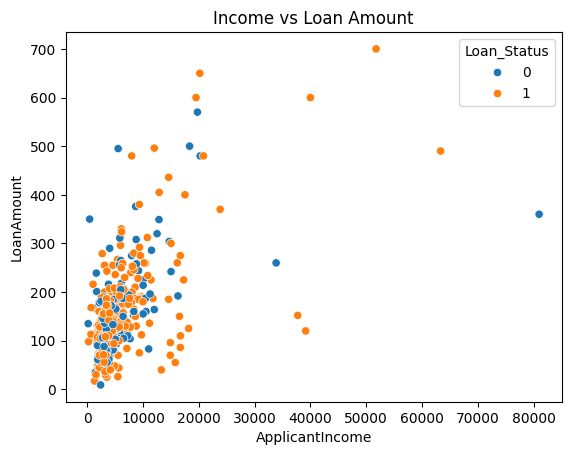

In [ ]:
plt.figure()
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=df)
plt.title("Income vs Loan Amount")
plt.show()

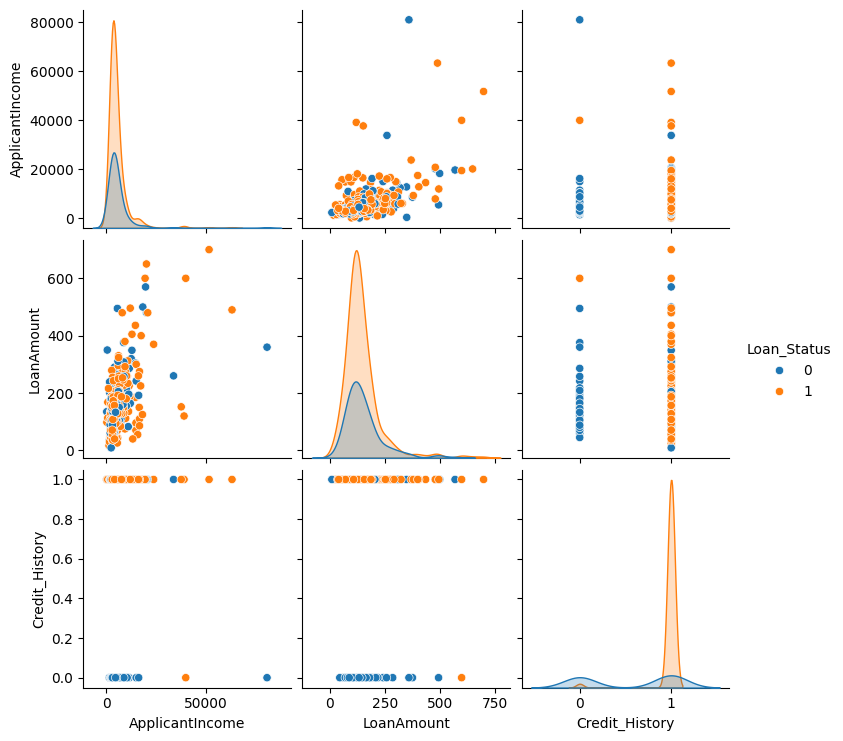

In [ ]:

sns.pairplot(df[['ApplicantIncome','LoanAmount','Credit_History','Loan_Status']], hue='Loan_Status')
plt.show()

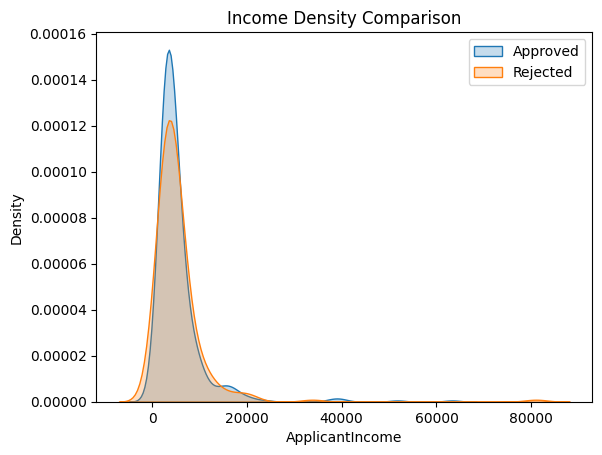

In [ ]:
plt.figure()
sns.kdeplot(df[df['Loan_Status']==1]['ApplicantIncome'], label='Approved', fill=True)
sns.kdeplot(df[df['Loan_Status']==0]['ApplicantIncome'], label='Rejected', fill=True)
plt.legend()
plt.title("Income Density Comparison")
plt.show()

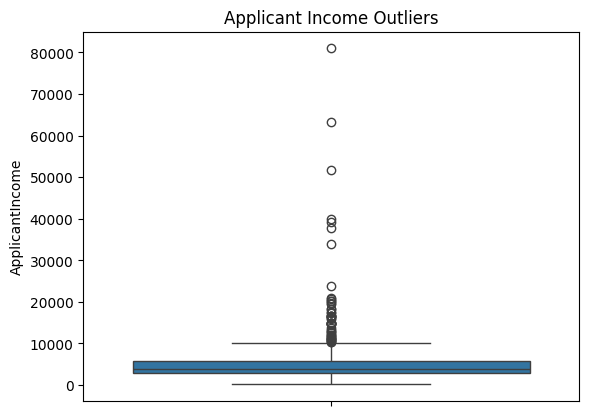

In [ ]:
plt.figure()
sns.boxplot(y='ApplicantIncome', data=df)
plt.title("Applicant Income Outliers")
plt.show()

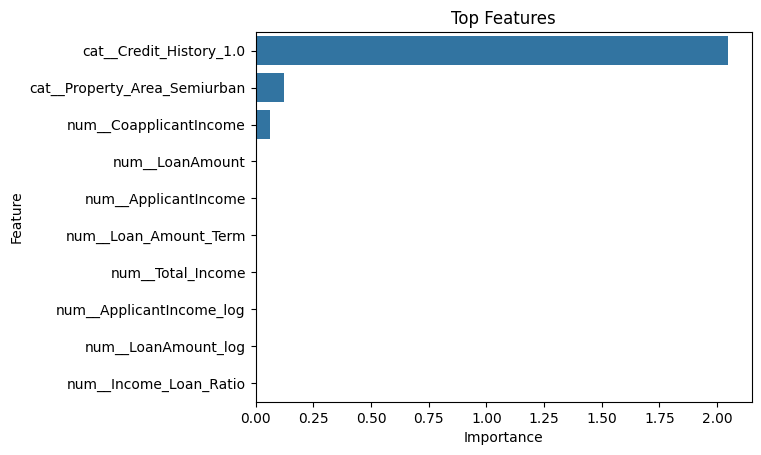

In [ ]:
plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Features")
plt.show()

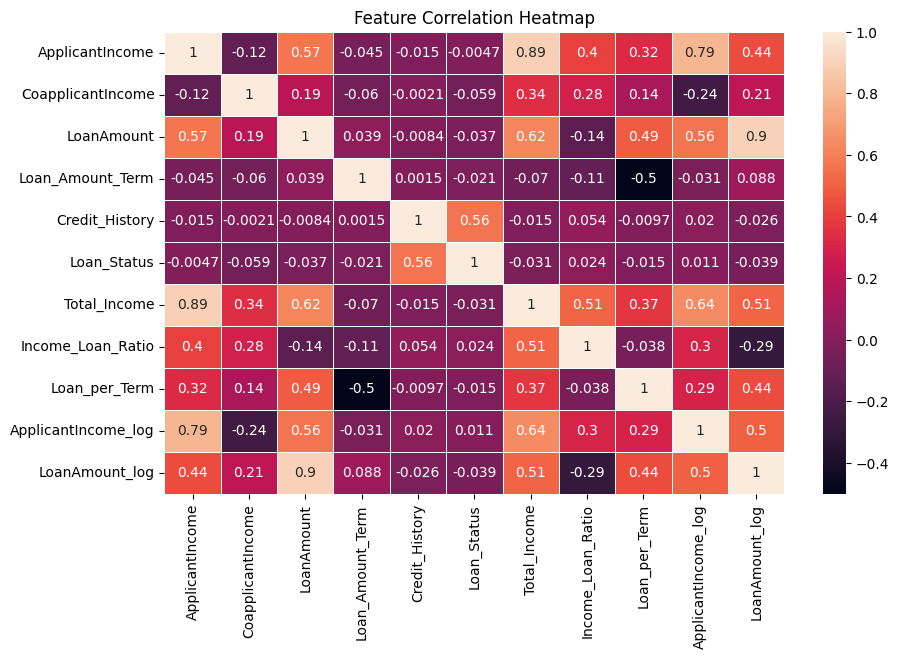

In [ ]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

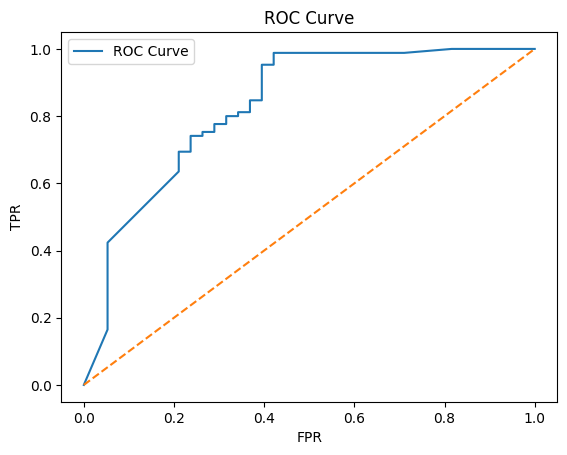

ROC-AUC: 0.8306501547987617


In [ ]:

# -------------------------------
# 13. ROC CURVE
# -------------------------------
y_prob = final_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_prob))


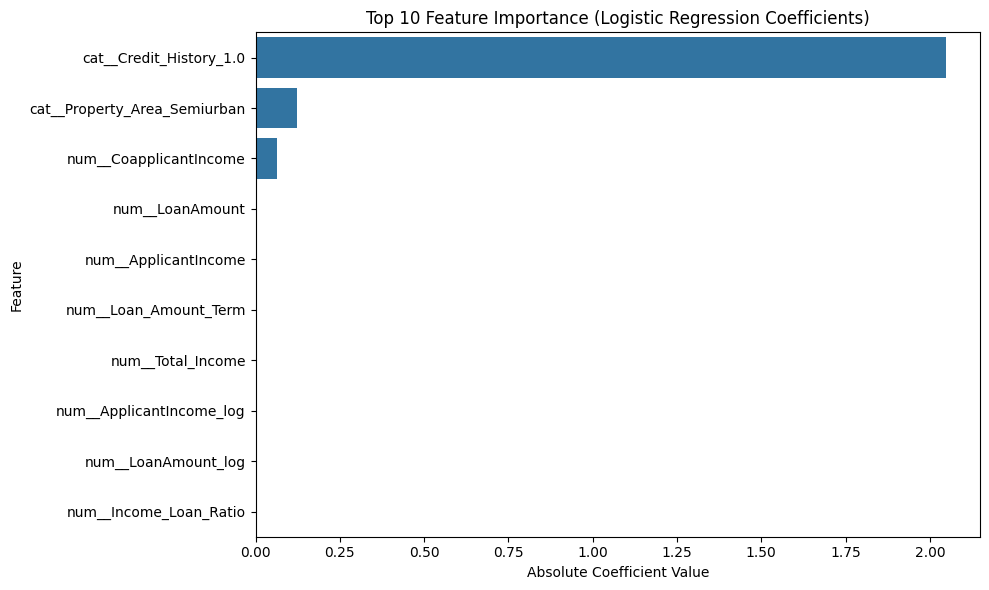

In [ ]:
# -------------------------------
# 14. FEATURE IMPORTANCE
# -------------------------------
classifier = final_model.named_steps['classifier']

# For Logistic Regression, coefficients indicate feature importance
if hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0]) # Take absolute value for importance
    feature_names = final_model.named_steps['preprocessing'].get_feature_names_out()

    feat_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
    plt.title("Top 10 Feature Importance (Logistic Regression Coefficients)")
    plt.xlabel("Absolute Coefficient Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not available for this type of classifier.")

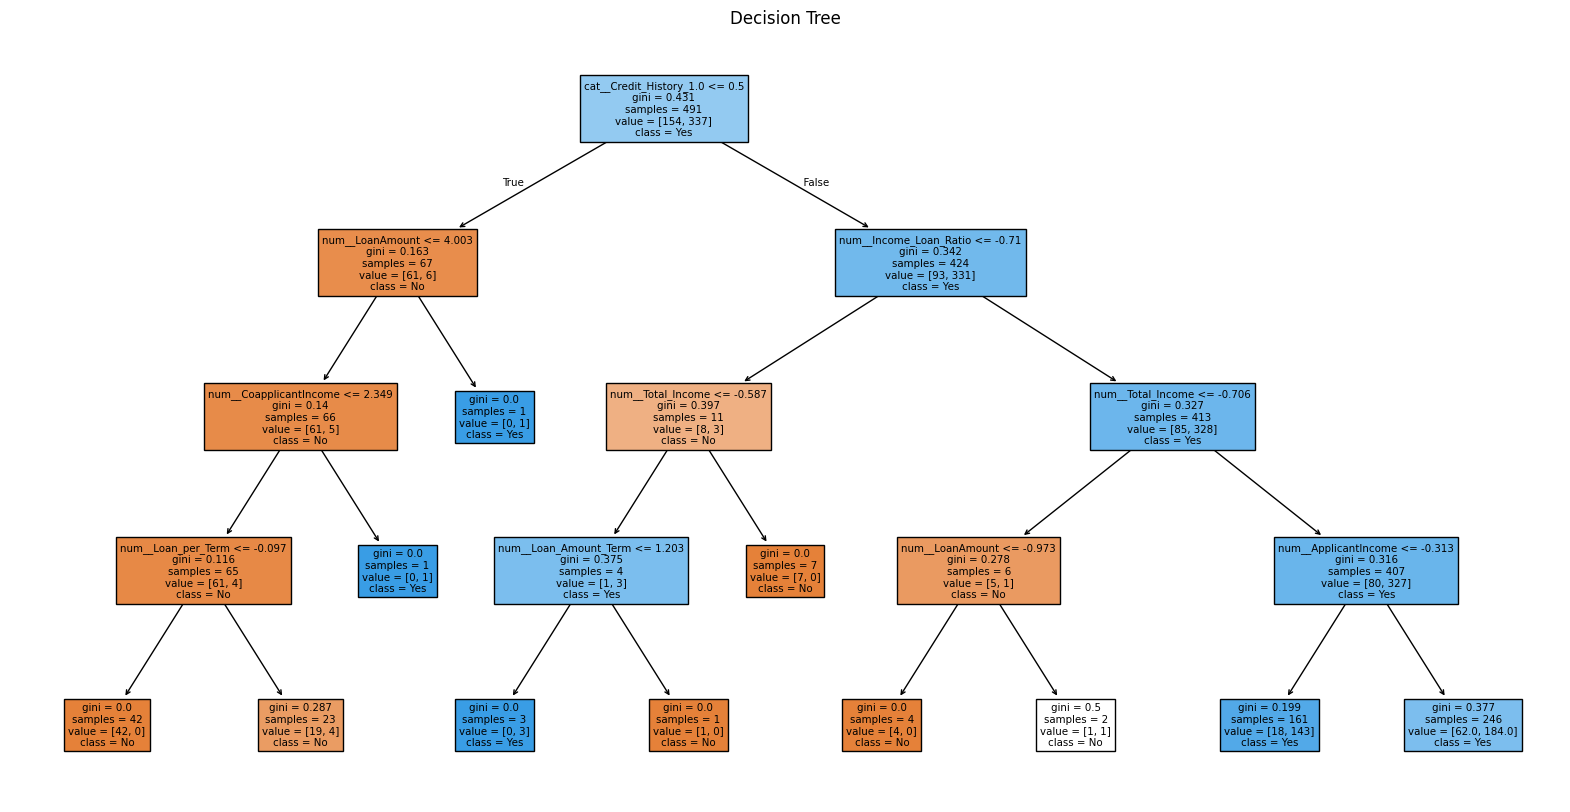

In [ ]:
# -------------------------------
# 15. DECISION TREE VISUALIZATION
# -------------------------------
dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

dt_pipeline.fit(X_train, y_train)

tree = dt_pipeline.named_steps['classifier']
feature_names_dt = dt_pipeline.named_steps['preprocessing'].get_feature_names_out()

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=feature_names_dt,
          class_names=["No","Yes"], filled=True)
plt.title("Decision Tree")
plt.show()


In [ ]:
# -------------------------------
# 16. SAVE MODEL
# -------------------------------
pickle.dump(final_model, open("loan_model.pkl", "wb"))
print("\nModel saved!")


Model saved!


In [ ]:

# -------------------------------
# 17. TEST DATA PREDICTION
# -------------------------------
test = pd.read_csv("/content/loan test dataset.csv")

loan_ids = test['Loan_ID']
test = test.drop('Loan_ID', axis=1)

# SAME FEATURE ENGINEERING ON TEST
test['Total_Income'] = test['ApplicantIncome'] + test['CoapplicantIncome']
test['Income_Loan_Ratio'] = test['Total_Income'] / test['LoanAmount']
test['Loan_per_Term'] = test['LoanAmount'] / test['Loan_Amount_Term']
test['ApplicantIncome_log'] = np.log1p(test['ApplicantIncome'])
test['LoanAmount_log'] = np.log1p(test['LoanAmount'])

preds = final_model.predict(test)
probs = final_model.predict_proba(test)[:,1]

preds = ['Y' if i == 1 else 'N' for i in preds]

output = pd.DataFrame({
    'Loan_ID': loan_ids,
    'Loan_Status': preds,
    'Probability': probs
})

output.to_csv("submission.csv", index=False)

print("\nSubmission file created: submission.csv")


Submission file created: submission.csv
